# 2a. Parameter Recovery & SBC

**Purpose**: Can we recover known parameters from synthetic data? Can we correctly
identify which model (BE vs SC) generated the data?

**Protocol**:
1. Generate synthetic animals from known BE and SC parameters
2. Recover parameters via grid-search CV and SBI
3. SBI tested with 3 stat sets: heuristics only, update matrix only, mixed
4. For each method: true vs recovered scatter, coverage, model identification accuracy

**Two modes**:
- `QUICK = True`: 5 synthetic animals, coarse grid, 5K SBI sims (~10–15 min)
- `QUICK = False`: loads pre-computed results from disk (run training separately)

---

**What this validates**:
- Parameter identifiability: which params can actually be recovered?
- Posterior calibration (SBC): are credible intervals honest?
- Model selection reliability: false positive rate for BE-vs-SC classification
- Stat set comparison: which summary stats are most informative?

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
from models.BE_core import BEParams, BEState, BEModel
from models.SC_core import SCParams, SCState, SCModel
from behav_utils.data.synthetic import sample_stimuli
from behav_utils.analysis.summary_stats import compute_summary_stats
from behav_utils.analysis.update_matrix import compute_update_matrix, matrix_error
from behav_utils.plotting.styles import COLOURS, apply_style

from analysis.grid_search import grid_search_cv, COARSE_GRID, DEFAULT_GRID
from analysis.cv_utils import format_params

apply_style()

## 1. Configuration

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODE
# ═══════════════════════════════════════════════════════════════════════════════
QUICK = True              # True = run everything in notebook (small scale)
                           # False = load pre-computed results from RESULTS_DIR

RESULTS_DIR = Path('../results/recovery')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# SYNTHETIC DATA PARAMETERS
# ═══════════════════════════════════════════════════════════════════════════════
if QUICK:
    N_SYNTHETIC = 5           # synthetic animals per model
    N_SESSIONS = 8            # sessions per synthetic animal
    TRIALS_PER_SESSION = 300  # trials per session
    BURN_IN = 500
    N_CV_SEEDS = 4            # grid-search CV seeds
    N_SBI_SIMS = 5_000        # SBI training simulations
    N_SBI_RECOVERY = 20       # SBI recovery tests
    N_SBC_RUNS = 50           # SBC iterations
    
    N_SYNTHETIC = 2           # synthetic animals per model
    N_SESSIONS = 2            # sessions per synthetic animal
    TRIALS_PER_SESSION = 300  # trials per session
    BURN_IN = 500
    N_CV_SEEDS = 2            # grid-search CV seeds
    N_SBI_SIMS = 500        # SBI training simulations
    N_SBI_RECOVERY = 20       # SBI recovery tests
    N_SBC_RUNS = 50           # SBC iterations
else:
    N_SYNTHETIC = 20
    N_SESSIONS = 10
    TRIALS_PER_SESSION = 300
    BURN_IN = 1000
    N_CV_SEEDS = 32
    N_SBI_SIMS = 50_000
    N_SBI_RECOVERY = 100
    N_SBC_RUNS = 500

# Stat sets for SBI
HEURISTIC_STATS = ['accuracy', 'psychometric', 'recency', 'win_stay', 'stimulus_sensitivity']
UM_STATS = ['update_matrix']
MIXED_STATS = HEURISTIC_STATS + UM_STATS

SEED = 42
print(f"Mode: {'QUICK' if QUICK else 'FULL'}")
print(f"  {N_SYNTHETIC} animals × {N_SESSIONS} sessions × {TRIALS_PER_SESSION} trials")
print(f"  Grid-search: {N_CV_SEEDS} seeds")
print(f"  SBI: {N_SBI_SIMS:,} sims, {N_SBI_RECOVERY} recovery tests, {N_SBC_RUNS} SBC runs")

Mode: QUICK
  2 animals × 2 sessions × 300 trials
  Grid-search: 2 seeds
  SBI: 500 sims, 20 recovery tests, 50 SBC runs


## 2. Generate Synthetic Data

Sample BE and SC parameters from the prior, simulate expert-like sessions,
store the trials in SessionData-like containers.

In [4]:
from behav_utils.data.synthetic import generate_synthetic_animal


def make_synthetic_animals(model_type, n_animals, n_sessions, trials_per_session,
                           burn_in, base_seed):
    """Generate synthetic animals with known parameters using make_simulator."""
    rng_gen = np.random.default_rng(base_seed)
    animals = []

    for i in range(n_animals):
        seed_i = base_seed + i * 100

        if model_type == 'BE':
            params = BEParams.sample_prior(rng_gen)
            sim = BEModel.make_simulator(params, burn_in=burn_in, seed=seed_i)
        else:
            params = SCParams.sample_prior(rng_gen)
            sim = SCModel.make_simulator(params, burn_in=burn_in, seed=seed_i)

        aid = f'{model_type}_synth_{i:02d}'
        animal, info = generate_synthetic_animal(
            animal_id=aid,
            n_sessions=n_sessions,
            trials_per_session=trials_per_session,
            seed=seed_i,
            simulator=sim,
            stage='Full_Task_Cont',
        )

        acc = np.mean([s.stats(['accuracy'])['accuracy'] for s in animal.sessions])

        animals.append({
            'animal_id': aid,
            'true_model': model_type,
            'true_params': params.to_dict(),
            'sessions': animal.sessions,
            'mean_accuracy': acc,
        })

    return animals

In [5]:
synthetic_animals = []
synthetic_animals.extend(make_synthetic_animals(
    'BE', N_SYNTHETIC, N_SESSIONS, TRIALS_PER_SESSION, BURN_IN, SEED,
))
synthetic_animals.extend(make_synthetic_animals(
    'SC', N_SYNTHETIC, N_SESSIONS, TRIALS_PER_SESSION, BURN_IN, SEED + 5000,
))

print(f"Generated {len(synthetic_animals)} synthetic animals "
      f"({N_SYNTHETIC} BE + {N_SYNTHETIC} SC)")
for a in synthetic_animals:
    p = a['true_params']
    param_str = ', '.join(f'{k}={v:.3f}' for k, v in p.items())
    print(f"  {a['animal_id']} [{a['true_model']}]: acc={a['mean_accuracy']:.2f}, {param_str}")

Generated 4 synthetic animals (2 BE + 2 SC)
  BE_synth_00 [BE]: acc=0.60, sigma_percep=0.398, A_repulsion=0.219, eta_learning=0.780, eta_relax=0.282
  BE_synth_01 [BE]: acc=0.62, sigma_percep=0.092, A_repulsion=0.488, eta_learning=0.697, eta_relax=0.317
  SC_synth_00 [SC]: acc=0.77, sigma_percep=0.159, A_repulsion=0.325, gamma=0.944, sigma_update=0.783
  SC_synth_01 [SC]: acc=0.77, sigma_percep=0.226, A_repulsion=0.226, gamma=0.898, sigma_update=0.732


## 3. Grid-Search Recovery

For each synthetic animal, run the grid-search CV and check:
- Does it pick the correct model?
- How close are the recovered parameters to ground truth?

In [6]:
grid = COARSE_GRID if QUICK else DEFAULT_GRID

gs_results = []  # one dict per synthetic animal

for sa in synthetic_animals:
    aid = sa['animal_id']
    sessions = sa['sessions']
    print(f"\n{aid} [{sa['true_model']}]...")

    be_errors, sc_errors = [], []
    be_params_list, sc_params_list = [], []

    for seed in range(1, N_CV_SEEDS + 1):
        for model_type, error_list, param_list in [
            ('BE', be_errors, be_params_list),
            ('SC', sc_errors, sc_params_list),
        ]:
            result = grid_search_cv(
                sessions, model_type, grid[model_type],
                n_folds=2, seed=seed, burn_in=BURN_IN,
            )
            error_list.append(result['avg_test_error'])
            param_list.append(result['best_params_single'])

    be_mean = np.mean(be_errors)
    sc_mean = np.mean(sc_errors)
    picked = 'BE' if be_mean < sc_mean else 'SC'
    correct = picked == sa['true_model']

    # Best params from the winning model's best seed
    if picked == 'BE':
        best_idx = np.argmin(be_errors)
        best_params = be_params_list[best_idx]
    else:
        best_idx = np.argmin(sc_errors)
        best_params = sc_params_list[best_idx]

    gs_results.append({
        'animal_id': aid,
        'true_model': sa['true_model'],
        'true_params': sa['true_params'],
        'picked_model': picked,
        'correct': correct,
        'be_mean_error': be_mean,
        'sc_mean_error': sc_mean,
        'recovered_params': best_params,
        'be_errors': be_errors,
        'sc_errors': sc_errors,
    })
    print(f"  BE={be_mean:.5f}  SC={sc_mean:.5f}  → {picked} "
          f"({'✓' if correct else '✗ WRONG'})")



BE_synth_00 [BE]...
  BE=0.03046  SC=0.04363  → BE (✓)

BE_synth_01 [BE]...
  BE=0.03641  SC=0.03869  → BE (✓)

SC_synth_00 [SC]...
  BE=0.04840  SC=0.03713  → SC (✓)

SC_synth_01 [SC]...
  BE=0.05006  SC=0.02311  → SC (✓)


In [7]:
# Summary
gs_df = pd.DataFrame(gs_results)
n_correct = gs_df['correct'].sum()
n_total = len(gs_df)
print(f"\nGrid-search model identification: {n_correct}/{n_total} "
      f"({n_correct/n_total:.0%})")


Grid-search model identification: 4/4 (100%)


### 3b. Grid-Search Parameter Recovery Scatter

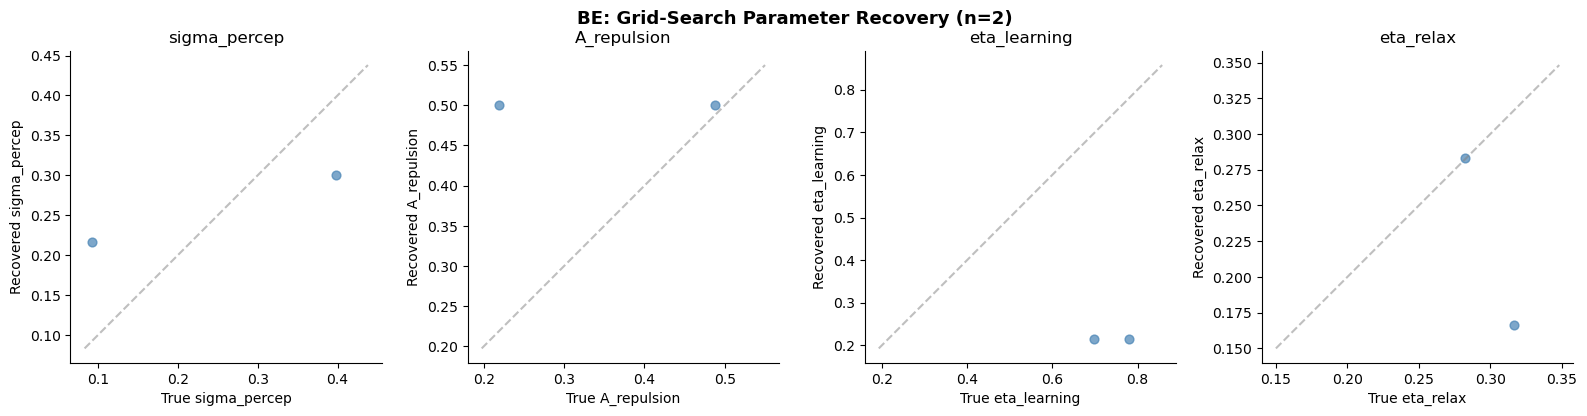

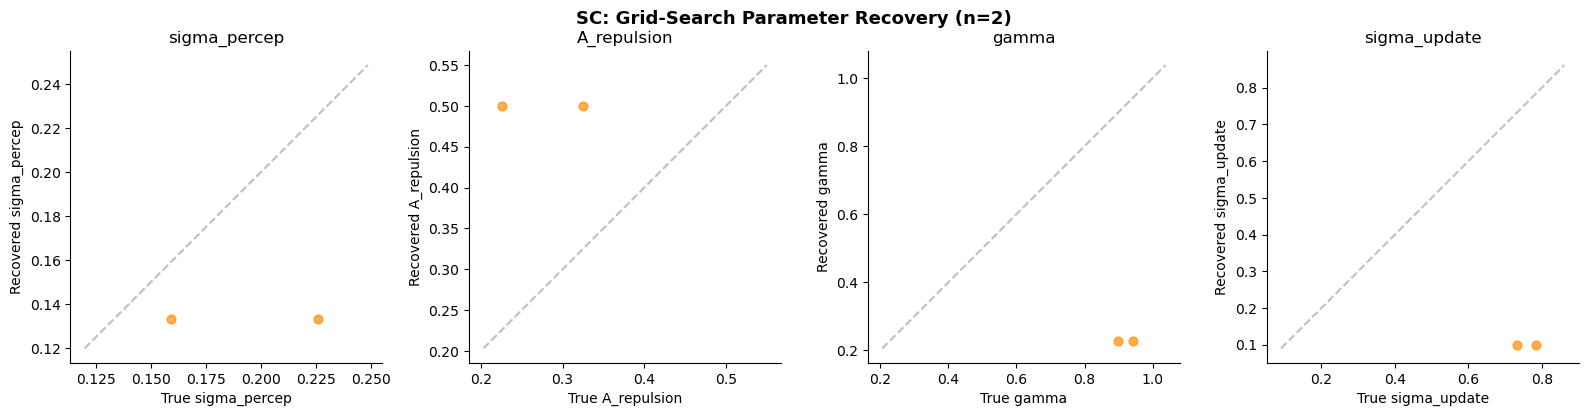

In [8]:
# Parameter recovery: true vs recovered for correctly-identified animals
for true_model in ['BE', 'SC']:
    sub = [r for r in gs_results
           if r['true_model'] == true_model and r['correct']]
    if len(sub) < 2:
        print(f"Not enough correct {true_model} recoveries for scatter")
        continue

    # Get param names for this model
    param_names = list(sub[0]['true_params'].keys())
    n_params = len(param_names)

    fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 4))
    if n_params == 1:
        axes = [axes]

    for ax, pname in zip(axes, param_names):
        true_vals = [r['true_params'][pname] for r in sub]
        # Map recovered param names
        rec_vals = []
        for r in sub:
            rp = r['recovered_params']
            # Handle sigma_percep vs sigma_noise naming
            if pname in rp:
                rec_vals.append(rp[pname])
            elif pname == 'sigma_percep' and 'sigma_noise' in rp:
                rec_vals.append(rp['sigma_noise'])
            elif pname == 'sigma_noise' and 'sigma_percep' in rp:
                rec_vals.append(rp['sigma_percep'])
            else:
                rec_vals.append(np.nan)

        ax.scatter(true_vals, rec_vals, c=COLOURS[true_model], alpha=0.7, s=40)
        lims = [min(min(true_vals), min(rec_vals)) * 0.9,
                max(max(true_vals), max(rec_vals)) * 1.1]
        ax.plot(lims, lims, '--', color='grey', alpha=0.5)
        ax.set_xlabel(f'True {pname}')
        ax.set_ylabel(f'Recovered {pname}')
        ax.set_title(pname)
        ax.set_aspect('equal')

    fig.suptitle(f'{true_model}: Grid-Search Parameter Recovery (n={len(sub)})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. SBI Recovery

Train SNPE with 3 different stat sets, then test parameter recovery.

In **quick mode**: trains in notebook (~2 min per network × 6 = ~12 min).
In **full mode**: loads pre-trained networks from disk.

In [9]:
try:
    import torch
    SBI_OK = True
    print(f"torch={torch.__version__}, "
          f"{'cuda' if torch.cuda.is_available() else 'cpu'}")
except ImportError:
    SBI_OK = False
    print("SBI not available — skipping SBI sections")

torch=2.5.1, cpu


In [10]:
if SBI_OK:
    from inference.simulator import (
        create_be_simulator, create_sc_simulator,
        get_sbi_prior, wrap_for_sbi,
    )
    from inference.diagnostics import (
        parameter_recovery, run_sbc,
        plot_recovery_scatter, plot_recovery_bias,
        plot_sbc_ranks,
    )

In [11]:
def train_or_load_snpe(model_type, stat_names, stat_label, n_sims, burn_in, seed):
    save_path = RESULTS_DIR / f'snpe_{model_type}_{stat_label}.pkl'

    n_trials = N_SESSIONS * TRIALS_PER_SESSION
    stim, cat = sample_stimuli(n_trials, 'uniform', np.random.default_rng(seed))
    creator = create_be_simulator if model_type == 'be' else create_sc_simulator
    sim = creator(stim, cat, stat_names=stat_names, burn_in=burn_in)
    prior = get_sbi_prior(sim)
    sbi_sim = wrap_for_sbi(sim)

    if not QUICK and save_path.exists():
        print(f"  Loading {save_path.name}...")
        with open(save_path, 'rb') as f:
            saved = pickle.load(f)
        return {
            **saved,
            'simulator': sim,
            'sbi_sim': sbi_sim,
            'prior': prior,
        }

    # Train
    from sbi.inference import SNPE

    print(f"  Training SNPE [{model_type.upper()}, {stat_label}] "
          f"({n_sims:,} sims)...", end=' ', flush=True)
    t0 = time.time()

    theta = prior.sample((n_sims,))
    x = torch.stack([sbi_sim(t) for t in theta])
    valid = ~torch.any(torch.isnan(x), dim=1)
    n_valid = valid.sum().item()

    inference = SNPE(prior=prior)
    inference.append_simulations(theta[valid], x[valid])
    posterior = inference.build_posterior(inference.train())

    dt = time.time() - t0
    print(f"{n_valid}/{n_sims} valid, {dt:.0f}s")

    # Save only picklable objects
    with open(save_path, 'wb') as f:
        pickle.dump({
            'posterior': posterior,
            'param_names': sim.get_param_names(),
            'stat_names': stat_names,
            'stat_label': stat_label,
            'model_type': model_type,
        }, f)

    return {
        'posterior': posterior,
        'prior': prior,
        'simulator': sim,
        'sbi_sim': sbi_sim,
        'param_names': sim.get_param_names(),
        'stat_names': stat_names,
        'stat_label': stat_label,
        'model_type': model_type,
    }

In [12]:
# Train 6 networks: 2 models × 3 stat sets
sbi_networks = {}  # (model_type, stat_label) -> trained network data

if SBI_OK:
    stat_configs = [
        ('heuristics', HEURISTIC_STATS),
        ('um_only', UM_STATS),
        ('mixed', MIXED_STATS),
    ]

    for model_type in ['be', 'sc']:
        for stat_label, stat_names in stat_configs:
            key = (model_type, stat_label)
            sbi_networks[key] = train_or_load_snpe(
                model_type, stat_names, stat_label,
                N_SBI_SIMS, BURN_IN, SEED,
            )

    print(f"\n{len(sbi_networks)} networks ready")
else:
    print("Skipping SBI training (torch not available)")

 Neural network successfully converged after 227 epochs.471/500 valid, 58s
 Neural network successfully converged after 71 epochs.500/500 valid, 89s
 Neural network successfully converged after 115 epochs.475/500 valid, 103s
 Neural network successfully converged after 187 epochs.500/500 valid, 93s
 Neural network successfully converged after 91 epochs.500/500 valid, 114s
 Neural network successfully converged after 94 epochs.499/500 valid, 120s

6 networks ready


### 4b. SBI Parameter Recovery

In [13]:
sbi_recovery_results = {}  # (model_type, stat_label) -> recovery dict

if SBI_OK:
    for (model_type, stat_label), net in sbi_networks.items():
        print(f"\nRecovery: {model_type.upper()} / {stat_label}")
        rec = parameter_recovery(
            posterior=net['posterior'],
            simulator=net['sbi_sim'],
            prior=net['prior'],
            n_recoveries=N_SBI_RECOVERY,
            n_posterior_samples=500,
            seed=SEED,
            param_names=net['param_names'],
        )
        sbi_recovery_results[(model_type, stat_label)] = rec

        print(f"  Valid: {rec['n_valid']}/{N_SBI_RECOVERY}")
        for j, name in enumerate(rec['param_names']):
            print(f"  {name}: r={rec['correlation'][j]:.3f}, "
                  f"RMSE={rec['rmse'][j]:.4f}, "
                  f"coverage={rec['coverage_90'][j]:.2f}")


Recovery: BE / heuristics


Recovery:  10%|█         | 2/20 [00:00<00:02,  6.86it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Recovery:  20%|██        | 4/20 [00:00<00:02,  6.91it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

Recovery:  95%|█████████▌| 19/20 [00:05<00:00,  3.59it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Recovery: 100%|██████████| 20/20 [00:05<00:00,  3.52it/s]

  Valid: 20/20
  sigma_percep: r=0.448, RMSE=0.1172, coverage=0.70
  A_repulsion: r=0.424, RMSE=0.1272, coverage=0.85
  gamma: r=0.527, RMSE=0.0531, coverage=0.70
  sigma_update: r=0.451, RMSE=0.2476, coverage=0.65


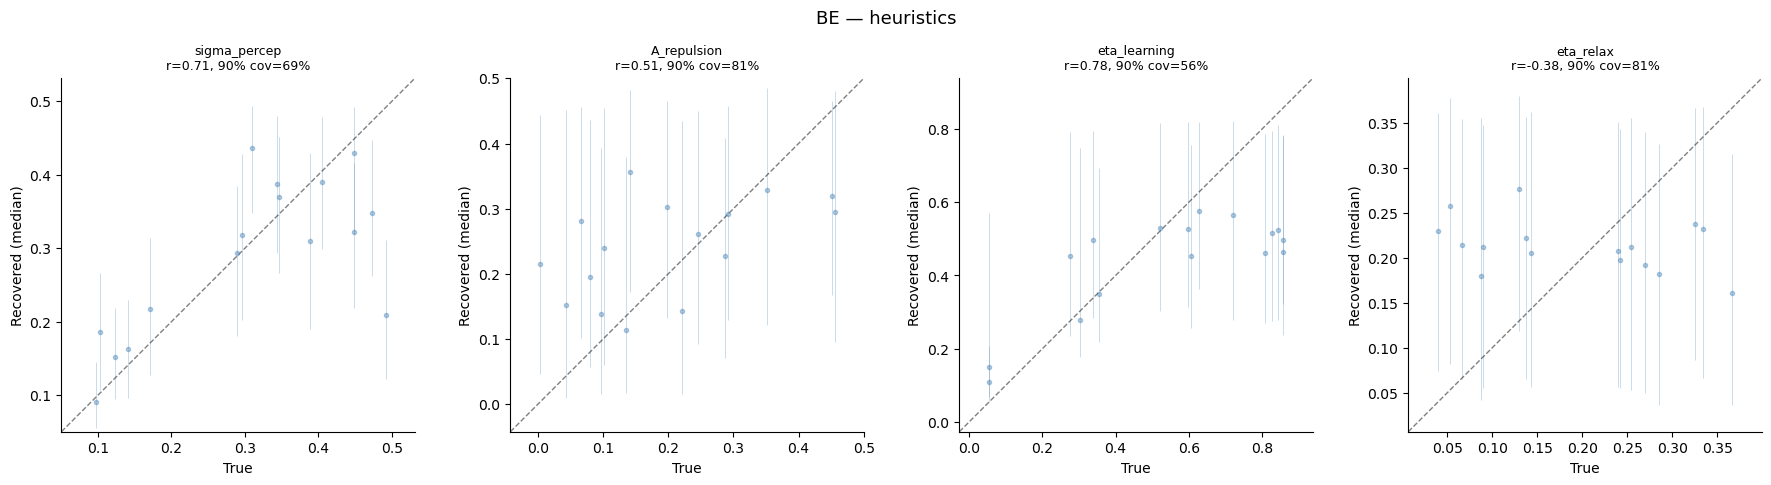

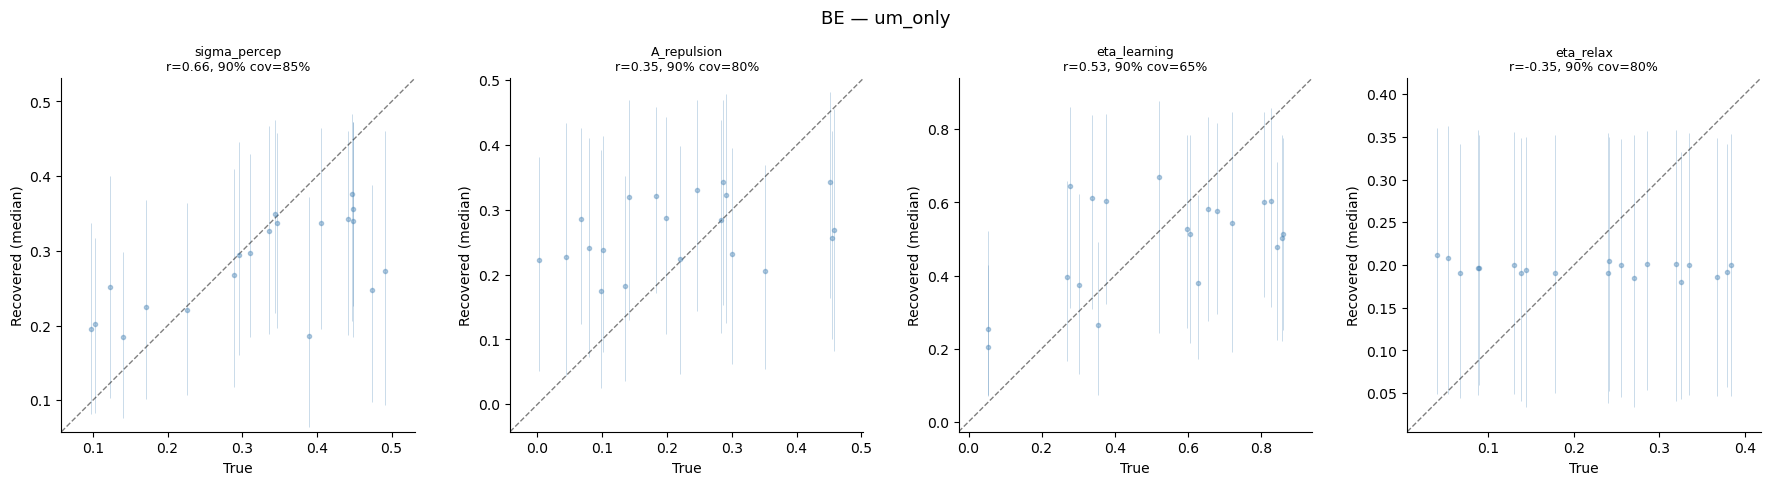

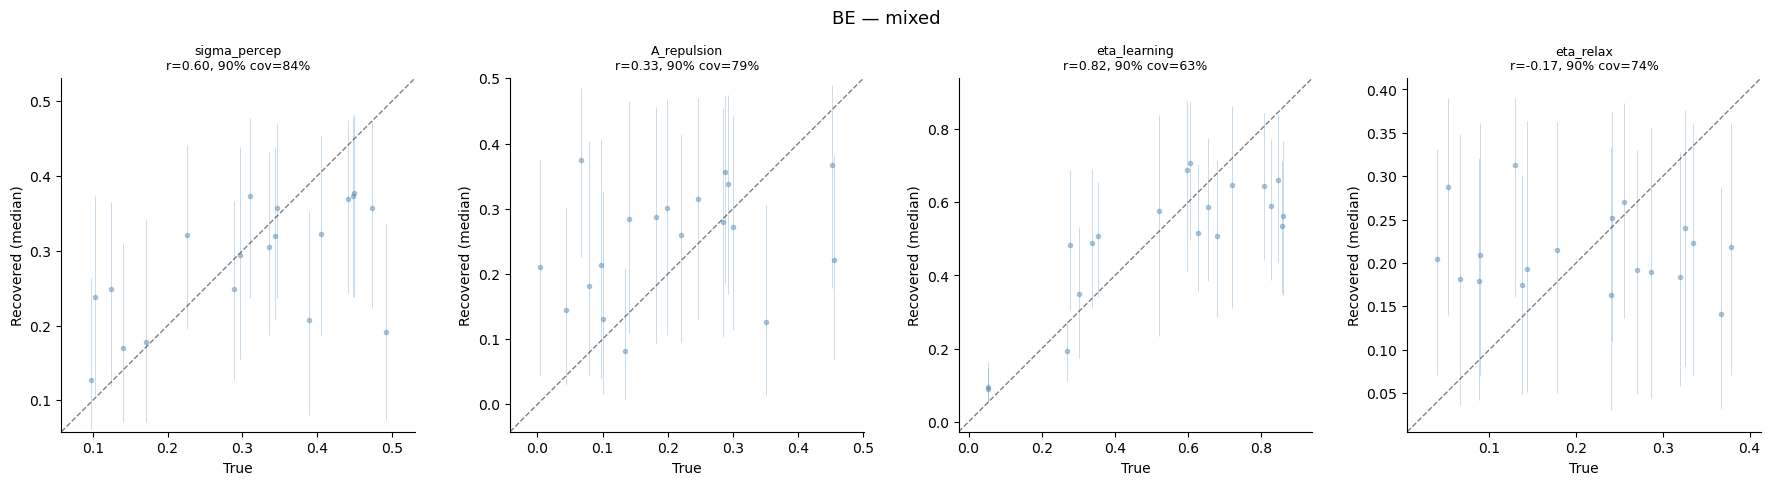

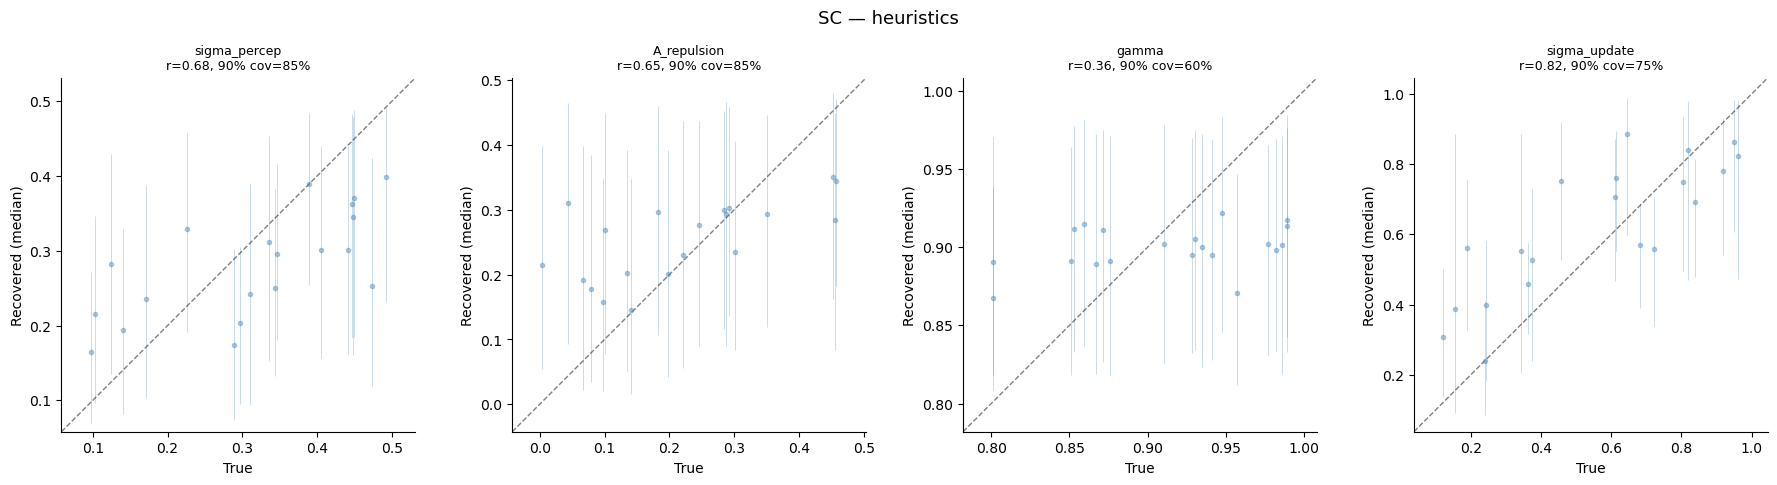

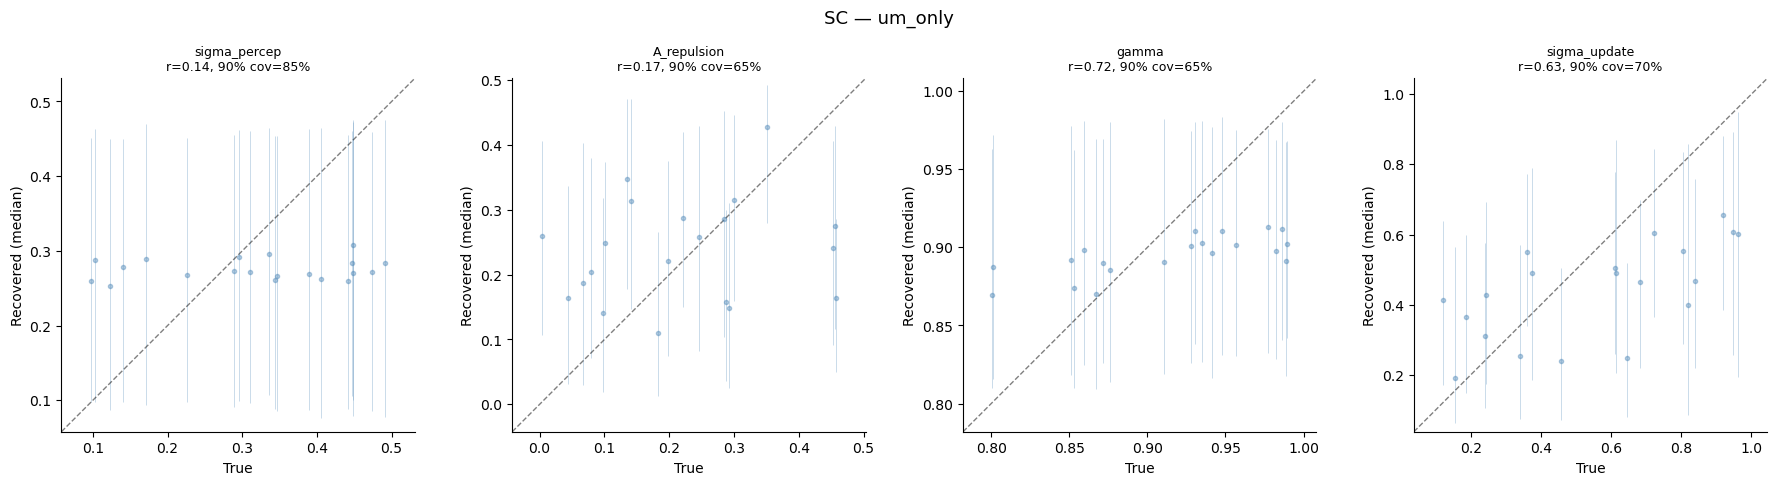

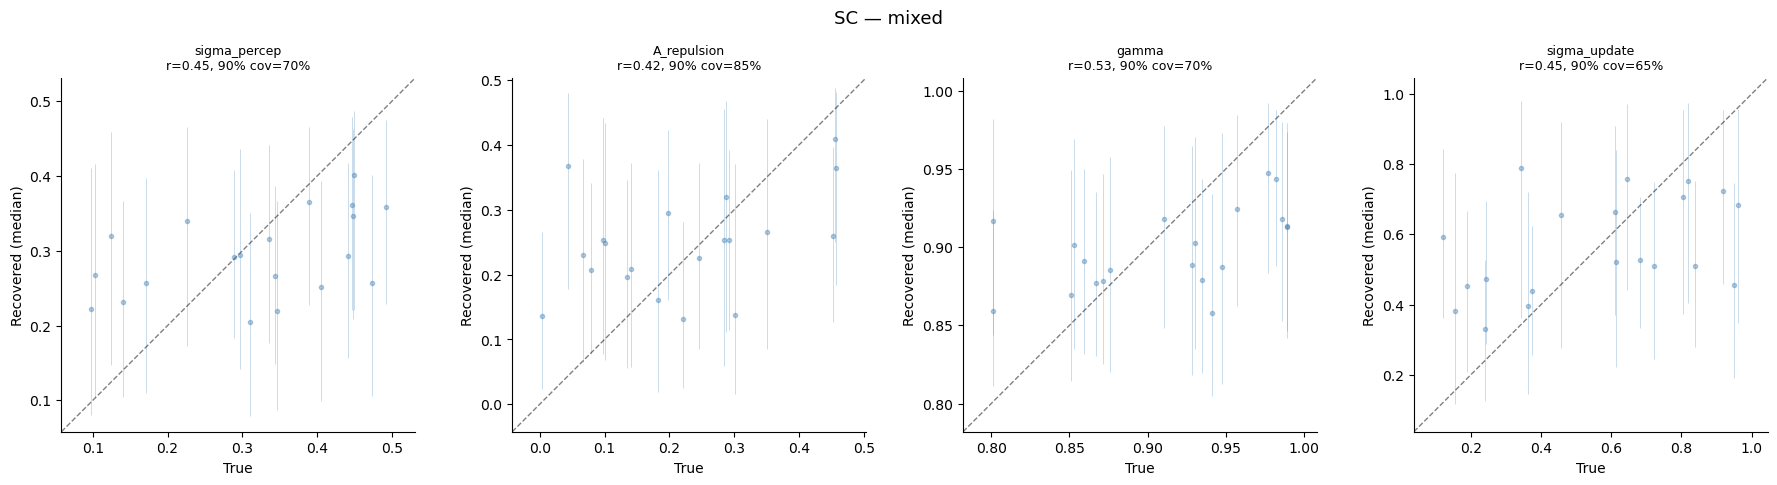

In [14]:
# Plot recovery scatters: one figure per model, columns = stat sets
if SBI_OK:
    for model_type in ['be', 'sc']:
        fig_rows = []
        stat_labels = ['heuristics', 'um_only', 'mixed']

        for stat_label in stat_labels:
            key = (model_type, stat_label)
            if key in sbi_recovery_results:
                rec = sbi_recovery_results[key]
                fig = plot_recovery_scatter(
                    rec,
                    title=f'{model_type.upper()} — {stat_label}',
                )
                plt.show()
                plt.close(fig)

### 4c. SBC Calibration Check

SBC: BE / heuristics... 

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

8s


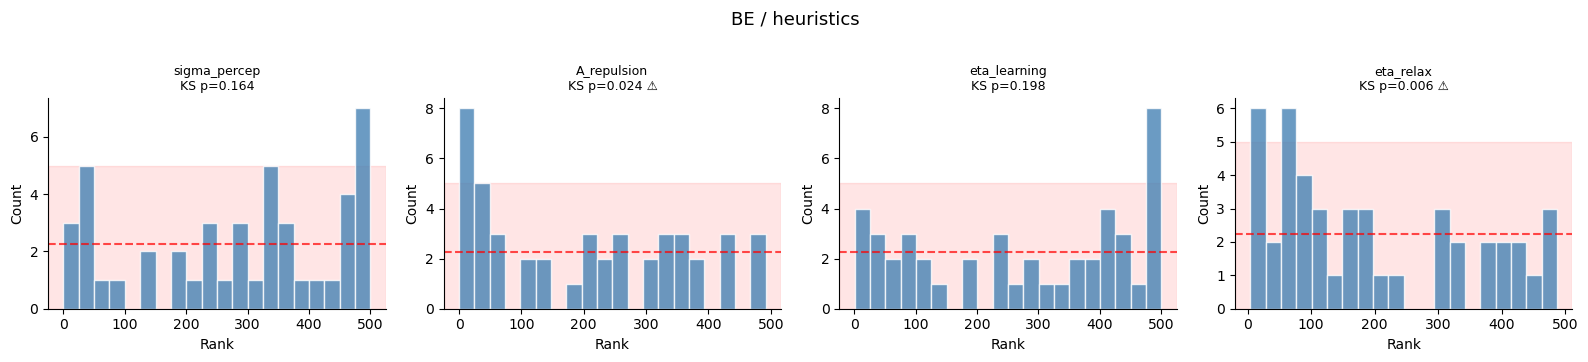

SBC: BE / um_only... 

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

11s


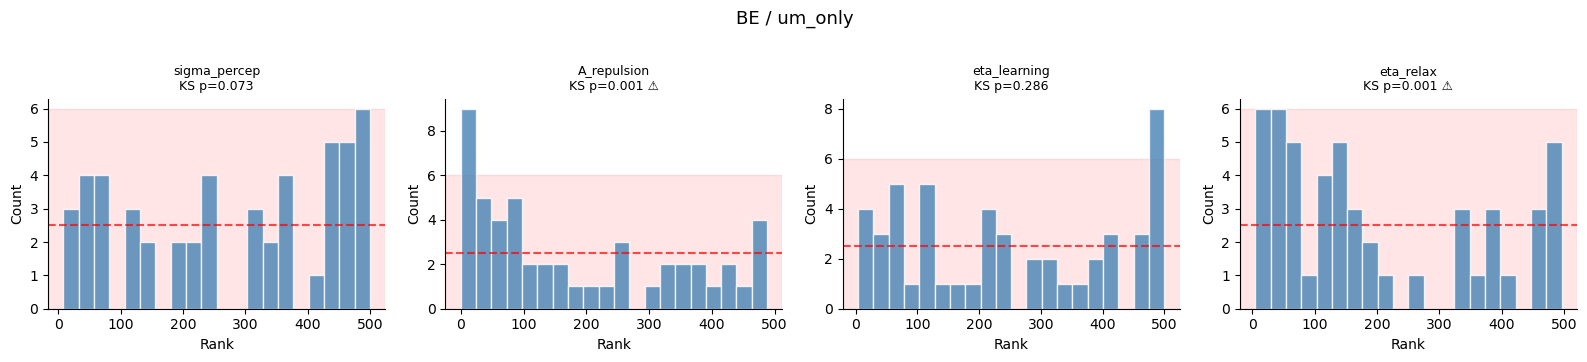

SBC: BE / mixed... 

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

12s


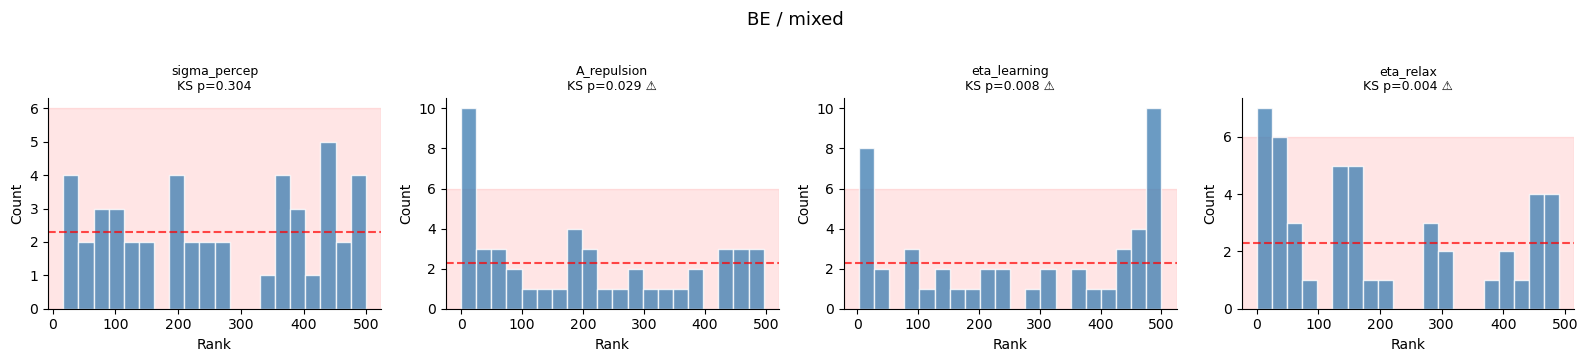

SBC: SC / heuristics... 

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

11s


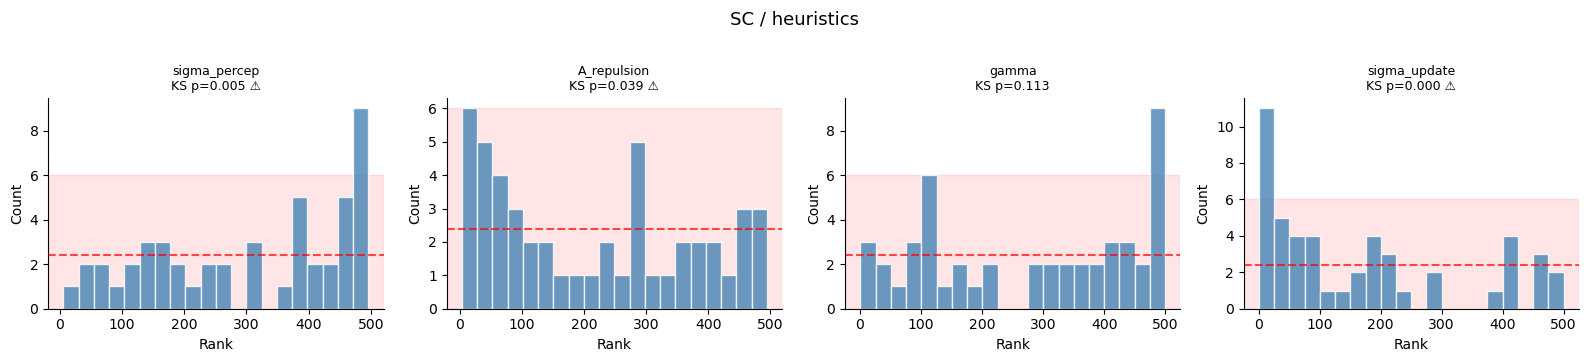

SBC: SC / um_only... 

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

13s


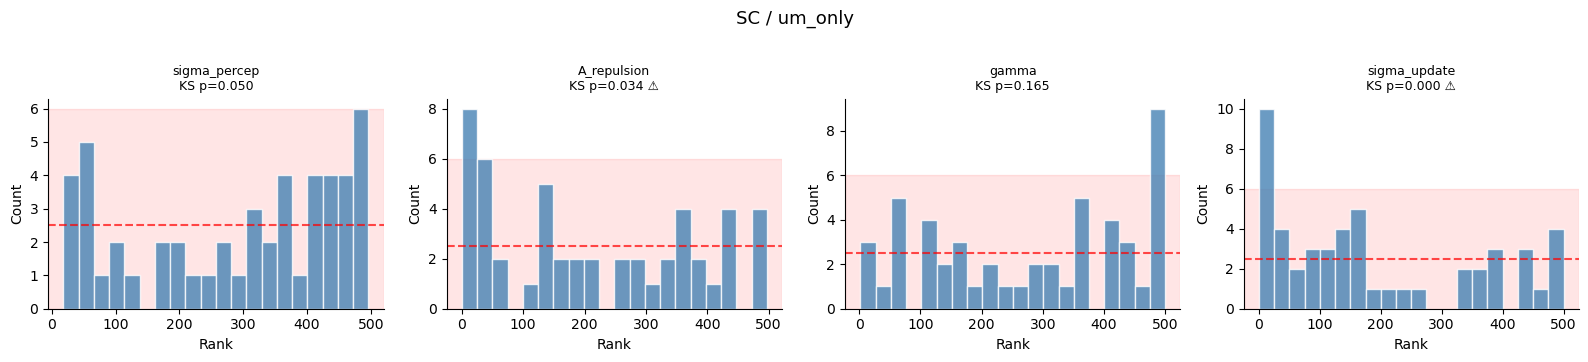

SBC: SC / mixed... 

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

15s


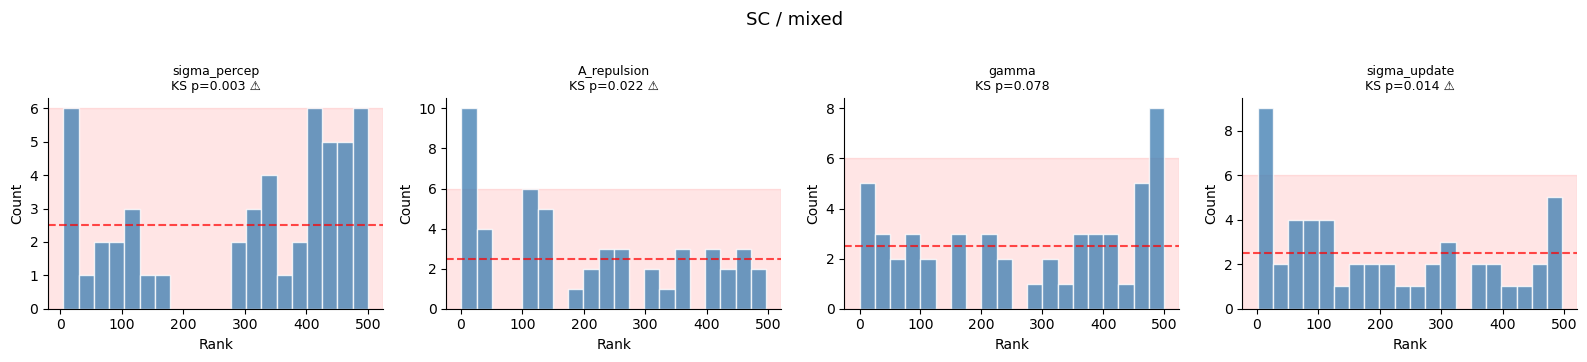

In [15]:
sbc_results = {}  # (model_type, stat_label) -> sbc dict

if SBI_OK:
    for (model_type, stat_label), net in sbi_networks.items():
        print(f"SBC: {model_type.upper()} / {stat_label}...", end=' ', flush=True)
        t0 = time.time()
        sbc = run_sbc(
            posterior=net['posterior'],
            simulator=net['sbi_sim'],
            prior=net['prior'],
            n_sbc_runs=N_SBC_RUNS,
            n_posterior_samples=500,
            seed=SEED,
            param_names=net['param_names'],
            show_progress=False,
        )
        sbc_results[(model_type, stat_label)] = sbc
        print(f"{time.time()-t0:.0f}s")

        fig = plot_sbc_ranks(sbc, title=f'{model_type.upper()} / {stat_label}')
        plt.show()
        plt.close(fig)

### 4d. SBI Model Identification

For each synthetic animal, condition both BE and SC posteriors on its data.
The model with higher marginal likelihood (or lower UM error) wins.

In [16]:
sbi_identification = []  # per synthetic animal, per stat set

if SBI_OK:
    for stat_label in ['heuristics', 'um_only', 'mixed']:
        be_net = sbi_networks.get(('be', stat_label))
        sc_net = sbi_networks.get(('sc', stat_label))
        if be_net is None or sc_net is None:
            continue

        print(f"\nModel identification via SBI [{stat_label}]")

        for sa in synthetic_animals:
            # Pool all sessions
            all_stim, all_cat, all_ch = [], [], []
            for sess in sa['sessions']:
                arrays = sess.trials.get_arrays()
                v = ~arrays['no_response']
                all_stim.append(arrays['stimuli'][v])
                all_cat.append(arrays['categories'][v])
                all_ch.append(arrays['choices'][v])
            stim = np.concatenate(all_stim)
            cat = np.concatenate(all_cat)
            ch = np.concatenate(all_ch)

            # Compute observed stats
            stat_names = be_net['stat_names']
            obs = compute_summary_stats(
                ch, stim, cat,
                stat_names=stat_names, return_dict=False,
            )
            obs = np.nan_to_num(obs, nan=0.0)
            x_obs = torch.tensor(obs, dtype=torch.float32)

            # Log prob under each posterior
            try:
                be_samples = be_net['posterior'].sample((200,), x=x_obs)
                sc_samples = sc_net['posterior'].sample((200,), x=x_obs)

                be_lp = be_net['posterior'].log_prob(be_samples, x=x_obs).mean().item()
                sc_lp = sc_net['posterior'].log_prob(sc_samples, x=x_obs).mean().item()
            except Exception as e:
                be_lp, sc_lp = np.nan, np.nan

            picked = 'BE' if be_lp > sc_lp else 'SC'
            correct = picked == sa['true_model']

            sbi_identification.append({
                'animal_id': sa['animal_id'],
                'true_model': sa['true_model'],
                'stat_set': stat_label,
                'picked_model': picked,
                'correct': correct,
                'be_log_prob': be_lp,
                'sc_log_prob': sc_lp,
            })

        sub = [r for r in sbi_identification if r['stat_set'] == stat_label]
        n_ok = sum(r['correct'] for r in sub)
        print(f"  {stat_label}: {n_ok}/{len(sub)} correct "
              f"({n_ok/len(sub):.0%})")

    sbi_id_df = pd.DataFrame(sbi_identification)


Model identification via SBI [heuristics]


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  mixed: 1/4 correct (25%)


## 5. Summary: Method Comparison

In [17]:
print("MODEL IDENTIFICATION ACCURACY")
print("=" * 50)

# Grid-search
gs_correct = gs_df['correct'].sum()
gs_total = len(gs_df)
print(f"Grid-search CV:  {gs_correct}/{gs_total} ({gs_correct/gs_total:.0%})")
for tm in ['BE', 'SC']:
    sub = gs_df[gs_df['true_model'] == tm]
    n = sub['correct'].sum()
    print(f"  True {tm}: {n}/{len(sub)}")

# SBI
if SBI_OK and len(sbi_identification) > 0:
    print()
    for stat_label in ['heuristics', 'um_only', 'mixed']:
        sub = sbi_id_df[sbi_id_df['stat_set'] == stat_label]
        n_ok = sub['correct'].sum()
        print(f"SBI ({stat_label:>10s}): {n_ok}/{len(sub)} "
              f"({n_ok/len(sub):.0%})")
        for tm in ['BE', 'SC']:
            ss = sub[sub['true_model'] == tm]
            n = ss['correct'].sum()
            print(f"  True {tm}: {n}/{len(ss)}")

MODEL IDENTIFICATION ACCURACY
Grid-search CV:  4/4 (100%)
  True BE: 2/2
  True SC: 2/2

SBI (heuristics): 2/4 (50%)
  True BE: 2/2
  True SC: 0/2
SBI (   um_only): 1/4 (25%)
  True BE: 0/2
  True SC: 1/2
SBI (     mixed): 1/4 (25%)
  True BE: 1/2
  True SC: 0/2


In [18]:
# Recovery quality comparison (SBI only)
if SBI_OK and sbi_recovery_results:
    rows = []
    for (model_type, stat_label), rec in sbi_recovery_results.items():
        for j, name in enumerate(rec['param_names']):
            rows.append({
                'model': model_type.upper(),
                'stat_set': stat_label,
                'param': name,
                'correlation': rec['correlation'][j],
                'rmse': rec['rmse'][j],
                'coverage_90': rec['coverage_90'][j],
                'bias': rec['bias'][j],
            })

    rec_df = pd.DataFrame(rows)
    print("\nSBI PARAMETER RECOVERY SUMMARY")
    print("=" * 70)
    for model_type in ['BE', 'SC']:
        sub = rec_df[rec_df['model'] == model_type]
        print(f"\n{model_type}:")
        pivot = sub.pivot_table(
            index='param',
            columns='stat_set',
            values=['correlation', 'coverage_90'],
        ).round(3)
        print(pivot.to_string())


SBI PARAMETER RECOVERY SUMMARY

BE:
             correlation                coverage_90               
stat_set      heuristics  mixed um_only  heuristics  mixed um_only
param                                                             
A_repulsion        0.507  0.332   0.351       0.812  0.789    0.80
eta_learning       0.778  0.815   0.527       0.562  0.632    0.65
eta_relax         -0.376 -0.172  -0.354       0.812  0.737    0.80
sigma_percep       0.708  0.604   0.664       0.688  0.842    0.85

SC:
             correlation                coverage_90              
stat_set      heuristics  mixed um_only  heuristics mixed um_only
param                                                            
A_repulsion        0.655  0.424   0.170        0.85  0.85    0.65
gamma              0.359  0.527   0.715        0.60  0.70    0.65
sigma_percep       0.677  0.448   0.144        0.85  0.70    0.85
sigma_update       0.823  0.451   0.630        0.75  0.65    0.70


## 6. Save Results

In [19]:
results = {
    'synthetic_animals': [
        {k: v for k, v in sa.items() if k != 'sessions'}
        for sa in synthetic_animals
    ],
    'grid_search': gs_results,
    'config': {
        'quick': QUICK, 'n_synthetic': N_SYNTHETIC,
        'n_sessions': N_SESSIONS, 'trials_per_session': TRIALS_PER_SESSION,
        'burn_in': BURN_IN, 'n_cv_seeds': N_CV_SEEDS,
        'n_sbi_sims': N_SBI_SIMS, 'n_sbi_recovery': N_SBI_RECOVERY,
    },
}

if SBI_OK:
    results['sbi_recovery'] = {
        k: {kk: vv for kk, vv in v.items() if not callable(vv)}
        for k, v in sbi_recovery_results.items()
    }
    results['sbi_identification'] = sbi_identification
    results['sbc'] = {
        k: {kk: vv for kk, vv in v.items()
            if isinstance(vv, (np.ndarray, list, str, int, float))}
        for k, v in sbc_results.items()
    }

save_path = RESULTS_DIR / f'recovery_results_{"quick" if QUICK else "full"}.pkl'
# with open(save_path, 'wb') as f:
#     pickle.dump(results, f)
# print(f"Saved: {save_path}")

## 7. Hard-A Distribution Recovery Test

Repeat the core recovery tests under Hard-A stimuli to check whether
parameter identifiability degrades when most stimuli concentrate near
the boundary.

**Expected:** σ_percep and A_repulsion become harder to recover
(fewer extreme-stimulus trials to anchor psychometric tails).
Learning rate parameters should remain identifiable.

In [20]:
from analysis.stimulus_distribution import sample_distribution

# ── Generate Hard-A synthetic data ────────────────────────────────────────
n_trials_hard = N_SESSIONS * TRIALS_PER_SESSION
rng_hard = np.random.default_rng(SEED + 999)
stim_hard, cat_hard = sample_distribution(n_trials_hard, 'Hard-A', rng=rng_hard)

print(f'Hard-A stimuli: {len(stim_hard)} trials')
print(f'  Category A (stim<0): {(stim_hard < 0).sum()} trials')
print(f'  Category B (stim>0): {(stim_hard > 0).sum()} trials')
print(f'  Near boundary (|stim|<0.25): {(np.abs(stim_hard) < 0.25).sum()} trials')

Hard-A stimuli: 600 trials
  Category A (stim<0): 296 trials
  Category B (stim>0): 304 trials
  Near boundary (|stim|<0.25): 184 trials


In [27]:
from sbi.inference import SNPE
# ── Train SNPE on Hard-A stimuli ─────────────────────────────────────────

HARD_A_STAT_NAMES = MIXED_STATS

hard_a_snpe = {}
if SBI_OK:
    for model_type in ['be', 'sc']:
        save_path = RESULTS_DIR / f'snpe_{model_type}_mixed_hardA.pkl'

        # Create simulator with Hard-A stimuli
        creator = create_be_simulator if model_type == 'be' else create_sc_simulator
        sim = creator(stim_hard, cat_hard, stat_names=HARD_A_STAT_NAMES, burn_in=BURN_IN)
        prior = get_sbi_prior(sim)
        sbi_sim = wrap_for_sbi(sim)

        if save_path.exists():
            print(f'Loading {save_path.name}')
            with open(save_path, 'rb') as f:
                saved = pickle.load(f)
            hard_a_snpe[model_type] = {
                **saved,
                'simulator': sim,
                'sbi_sim': sbi_sim,
                'prior': prior,
            }
        else:
            print(f'Training {model_type.upper()} on Hard-A stimuli...', end=' ', flush=True)
            t0 = time.time()

            theta = prior.sample((N_SBI_SIMS,))
            x = torch.stack([sbi_sim(t) for t in theta])
            valid = ~torch.any(torch.isnan(x), dim=1)
            n_valid = valid.sum().item()

            inference = SNPE(prior=prior)
            inference.append_simulations(theta[valid], x[valid])
            posterior = inference.build_posterior(inference.train())

            dt = time.time() - t0
            print(f'{n_valid}/{N_SBI_SIMS} valid, {dt:.0f}s')

            result = {
                'posterior': posterior,
                'param_names': sim.get_param_names(),
                'stat_names': HARD_A_STAT_NAMES,
                'model_type': model_type,
                'distribution': 'Hard-A',
            }
            with open(save_path, 'wb') as f:
                pickle.dump(result, f)

            hard_a_snpe[model_type] = {
                **result,
                'simulator': sim,
                'sbi_sim': sbi_sim,
                'prior': prior,
            }

 Neural network successfully converged after 92 epochs.448/500 valid, 329s
 Neural network successfully converged after 76 epochs.498/500 valid, 318s


In [28]:
# ── Recovery test on Hard-A ──────────────────────────────────────────────
HARD_A_STAT_NAMES = MIXED_STATS  # same stat set as Uniform analysis
hard_a_recovery = {}

if SBI_OK and hard_a_snpe:
    for model_type in ['BE', 'SC']:
        if model_type not in hard_a_snpe:
            continue

        posterior = hard_a_snpe[model_type]['posterior']
        prior = hard_a_snpe[model_type]['prior']

        # Use same synthetic animals but simulate with Hard-A stimuli
        true_params_list = []
        recovered_params_list = []

        for sa in synthetic_animals:
            if sa['model_type'] != model_type:
                continue

            # Simulate this animal's params on Hard-A stimuli
            params_dict = sa['params']
            creator = create_be_simulator if model_type == 'BE' else create_sc_simulator
            sim = creator(
                stimuli=stim_hard, categories=cat_hard,
                stat_names=HARD_A_STAT_NAMES,
                burn_in=BURN_IN,
            )
            # Generate observed stats
            theta_true = torch.tensor([list(params_dict.values())], dtype=torch.float32)
            x_obs = sim(theta_true)

            # Condition posterior
            try:
                samples = posterior.sample((1000,), x=x_obs,
                                           max_sampling_batch_size=1000)
                recovered = samples.mean(dim=0).numpy()
                true_params_list.append(list(params_dict.values()))
                recovered_params_list.append(recovered)
            except Exception as e:
                print(f'  Failed for {sa["animal_id"]}: {e}')

        if true_params_list:
            true_arr = np.array(true_params_list)
            rec_arr = np.array(recovered_params_list)
            hard_a_recovery[model_type] = {
                'true': true_arr, 'recovered': rec_arr,
            }

    print('Hard-A recovery complete')

Hard-A recovery complete


In [29]:
# ── Compare Uniform vs Hard-A recovery ───────────────────────────────────
if hard_a_recovery:
    for model_type in ['BE', 'SC']:
        if model_type not in hard_a_recovery:
            continue

        true_h = hard_a_recovery[model_type]['true']
        rec_h = hard_a_recovery[model_type]['recovered']
        param_names = (
            BEParams.get_param_names() if model_type == 'BE'
            else SCParams.get_param_names()
        )

        n_params = len(param_names)
        fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 4))

        for j, pname in enumerate(param_names):
            ax = axes[j]
            ax.scatter(true_h[:, j], rec_h[:, j], s=30, alpha=0.6,
                       color='darkorange', label='Hard-A')

            # Add Uniform recovery for comparison (from earlier results)
            # This assumes sbi_recovery_results exists from Section 4b
            key_uniform = (model_type, HARD_A_STAT_LABEL)
            if key_uniform in sbi_recovery_results:
                ur = sbi_recovery_results[key_uniform]
                ax.scatter(ur['true'][:, j], ur['recovered'][:, j],
                           s=30, alpha=0.4, color='steelblue', label='Uniform')

            lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
                    max(ax.get_xlim()[1], ax.get_ylim()[1])]
            ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.3)
            ax.set_xlabel('True')
            ax.set_ylabel('Recovered')
            ax.set_title(pname, fontsize=10)

            # R² comparison
            r2_hard = 1 - np.sum((rec_h[:, j] - true_h[:, j])**2) / (
                np.sum((true_h[:, j] - true_h[:, j].mean())**2) + 1e-10)
            ax.annotate(f'R²={r2_hard:.2f}', xy=(0.05, 0.95),
                        xycoords='axes fraction', fontsize=8,
                        color='darkorange', va='top')

        axes[0].legend(fontsize=7)
        fig.suptitle(f'{model_type}: Uniform vs Hard-A Recovery',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print('No Hard-A recovery results — SBI not available or no synthetic data')

No Hard-A recovery results — SBI not available or no synthetic data


## 8. GP-Linked Trajectory Recovery

The previous sections test recovery of **static** parameters.
But the scientific question (how do parameters change across sessions?)
requires **trajectory** recovery: can SBI with GP priors recover the
*shape* of a parameter trajectory?

**Protocol:**
1. Generate ground truth: η starts high (0.5) and decays to expert (0.1)
   over 20 sessions, with other params constant
2. Simulate behaviour at each session
3. Fit with GP-linked SBI (from inference/sbi_fitter.py)
4. Check: does the recovered trajectory match the true decay?

This is the validation for notebook 4b.

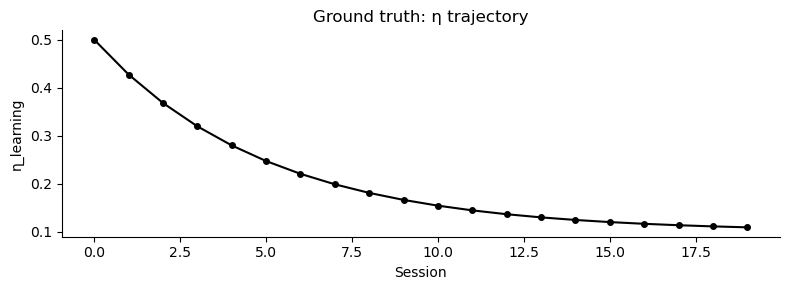

In [33]:
# ── Define ground truth trajectory ───────────────────────────────────────

N_SESSIONS_TRAJ = 20
TRIALS_PER_SESSION_TRAJ = 300

# True eta trajectory: exponential decay from 0.5 to 0.1
sessions_t = np.arange(N_SESSIONS_TRAJ)
true_eta = 0.1 + 0.4 * np.exp(-sessions_t / 5.0)

# Other params constant
TRUE_CONST = {
    'sigma_percep': 0.15,
    'A_repulsion': 0.10,
    'eta_relax': 0.12,
}

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(sessions_t, true_eta, 'ko-', ms=4)
ax.set_xlabel('Session')
ax.set_ylabel('η_learning')
ax.set_title('Ground truth: η trajectory')
plt.tight_layout()
plt.show()

In [34]:
# ── Simulate multi-session data with varying eta ──────────────────────────

rng_traj = np.random.default_rng(SEED)
traj_stimuli = []
traj_categories = []
traj_choices = []

state = BEModel.create_initial_state(
    burn_in=BURN_IN,
    params=BEParams(eta_learning=true_eta[0], **TRUE_CONST),
    seed=SEED,
)

for s_idx in range(N_SESSIONS_TRAJ):
    params = BEParams(eta_learning=float(true_eta[s_idx]), **TRUE_CONST)
    stim_s, cat_s = sample_distribution(
        TRIALS_PER_SESSION_TRAJ, 'Uniform', rng=rng_traj,
    )
    choices_s, _, state, _ = BEModel.simulate_session(
        params, state, stim_s, cat_s, rng_traj,
    )
    traj_stimuli.append(stim_s)
    traj_categories.append(cat_s)
    traj_choices.append(choices_s)

print(f'Generated {N_SESSIONS_TRAJ} sessions with varying η')

Generated 20 sessions with varying η


In [35]:
# ── Fit with GP-linked SBI ───────────────────────────────────────────────
# This uses the SBIFitter from inference/sbi_fitter.py
# If not available, this cell serves as a template for when it's ready

try:
    from inference.sbi_fitter import SBIFitter
    from inference.types import ModelType, GPLink, ConstantLink
    FITTER_OK = True
except ImportError:
    FITTER_OK = False
    print('SBIFitter not available — showing protocol only')

if SBI_OK and FITTER_OK:
    # Build FittingData from the synthetic trajectory
    from behav_utils.data.structures import FittingData

    fd = FittingData(
        animal_id='synthetic_trajectory',
        session_ids=[f'S{i}' for i in range(N_SESSIONS_TRAJ)],
        session_dates=[None] * N_SESSIONS_TRAJ,
        session_indices=np.arange(N_SESSIONS_TRAJ),
        stimuli=traj_stimuli,
        categories=traj_categories,
        choices=traj_choices,
        no_response=[np.isnan(c) for c in traj_choices],
        not_blockstart=[np.concatenate([[False], np.ones(len(s)-1, dtype=bool)])
                         for s in traj_stimuli],
        n_sessions=N_SESSIONS_TRAJ,
        trials_per_session=np.array([len(s) for s in traj_stimuli]),
    )

    # Define links: eta_learning varies via GP, others constant
    links = {
        'sigma_percep': ConstantLink(bounds=(0.05, 0.30)),
        'A_repulsion':  ConstantLink(bounds=(0.0, 0.5)),
        'eta_learning': GPLink(bounds=(0.01, 0.9), lengthscale=5.0),
        'eta_relax':    ConstantLink(bounds=(0.01, 0.4)),
    }

    print('GP-linked SBI setup ready')
    print('TODO: run fitter.fit(fd, links) — this is compute-intensive')
    print('Template for notebook 4b.')
else:
    print('GP-linked SBI requires SBIFitter — will be validated in 4b')

NameError: name 'DEFAULT_BE_PARAM_LINKS' is not defined

### Summary

**Hard-A recovery:** If R² drops significantly for σ_percep or A_repulsion
but stays stable for η, this means: (a) expert-phase parameter estimates
are reliable, (b) post-shift perceptual parameter estimates should be
interpreted cautiously, (c) learning rate tracking remains valid.

**GP-linked trajectory recovery:** If the pipeline recovers the exponential
decay shape of η, the tool is validated for tracking real parameter
changes in notebook 4b. If it doesn't, the GP prior may need tuning
(lengthscale, amplitude) or the stat set may need expanding.